## Analysis For IMDB Dataset
- In this project , I will work on IMDB dataset which has some movies properties 

### IMDB Dataset Field Description
---
- Below is a description of column fields in the Dataset:
---
#### Core Fields
- **`id`**:unique identifier for each movie
- **`popularity`**:Numeric Value that represent the movie popularity
                            

### Questions to be Answered depending on the Analysis 
1. what are the properties which will be associated with highly rated movies ?
2. Do Specific Genre tends to higher votes?
3. Top Directors
4. what are the top Cast?
5. Do high revenue movies affect high votes ?
6. Do higher-budjet movies lead to more Revenue ?
7. what are the periods in which there are highly rated movies ?
8. relation between runtime and vote.
9. Top Production Companies 

In [2]:
#load needed modules
import pandas as pd

In [3]:
#dissplay all data colmmes
pd.options.display.max_columns=None

## Data Wrangling
  *Data asseing by printing the first five rowes*

In [4]:
#load the dataset into data frame
df=pd.read_csv(r"D:\مشروعات تحليل بيانات\tmdb-movies (1).csv")

In [5]:
#display first rws
df.head(2)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08


In [6]:
#chee; for data size
df.shape

(10866, 21)

In [7]:
#cheek for data info (quilty)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

- some columns have missing values
- release Date column needs to be converted into Date Format
- there are some columns to be dropped (['imdb_id','homepage','budget','revenue','tagline',])
- Some columns need to be fixed ('production_companies','genres')
- rename some columns to be more readable

#### Feature Engineering
- add 3 columns to extract the main genre , main production company , main actor
- cast , prod_company , henres to be exploded 
- add column to specify movie season
- add profit column
- add success label column to check if the movie profitable or not
- add ROI column by dividing profit over budjet
- add column to classify high rated movies and low rated

In [8]:
#copy the data frame
df_copy=df.copy()

In [9]:
#cheek for duplicates
df.duplicated().sum()

np.int64(1)

only one duplicated row

In [10]:
# cheek for null values
df.isnull().sum()

id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

In [11]:
df[df.isnull().any(axis=1)]


,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,keywords,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
18,150689,tt1661199,5.556818,95000000,542351353,Cinderella,Lily James|Cate Blanchett|Richard Madden|Helen...,NaN,Kenneth Branagh,Midnight is just the beginning.,cinderella|magic|fairy tale|princess|shoe,"When her father unexpectedly passes away, youn...",112,Romance|Fantasy|Family|Drama,Walt Disney Pictures|Genre Films|Beagle Pug Fi...,3/12/15,1495,6.8,2015,8.739996e+07,4.989630e+08
21,307081,tt1798684,5.337064,30000000,91709827,Southpaw,Jake Gyllenhaal|Rachel McAdams|Forest Whitaker...,NaN,Antoine Fuqua,Believe in Hope.,sport,"Billy ""The Great"" Hope, the reigning junior mi...",123,Action|Drama,Escape Artists|Riche-Ludwig Productions,6/15/15,1386,7.3,2015,2.759999e+07,8.437300e+07
26,214756,tt2637276,4.564549,68000000,215863606,Ted 2,Mark Wahlberg|Seth MacFarlane|Amanda Seyfried|...,NaN,Seth MacFarlane,"Ted is Coming, Again.",sperm bank|sequel|buddy|courthouse|teddy bear,Newlywed couple Ted and Tami-Lynn want to have...,115,Comedy,Universal Pictures|Media Rights Capital|Fuzzy ...,6/25/15,1666,6.3,2015,6.255997e+07,1.985944e+08
32,254470,tt2848292,3.877764,29000000,287506194,Pitch Perfect 2,Anna Kendrick|Rebel Wilson|Hailee Steinfeld|Br...,NaN,Elizabeth Banks,We're back pitches,music|sequel|singer|male female relationship|a...,"The Bellas are back, and they are better than ...",115,Comedy|Music,Universal Pictures|Gold Circle Films|Brownston...,5/7/15,1264,6.8,2015,2.667999e+07,2.645056e+08
33,296098,tt3682448,3.648210,40000000,162610473,Bridge of Spies,Tom Hanks|Mark Rylance|Amy Ryan|Alan Alda|Seba...,NaN,Steven Spielberg,"In the shadow of war, one man showed the world...",spy|cia|cold war|pilot|lawyer,"During the Cold War, the Soviet Union captures...",141,Thriller|Drama,DreamWorks SKG|Amblin Entertainment|Studio Bab...,10/15/15,1638,7.1,2015,3.679998e+07,1.496016e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10861,21,tt0060371,0.080598,0,0,The Endless Summer,Michael Hynson|Robert August|Lord 'Tally Ho' B...,NaN,Bruce Brown,NaN,surfer|surfboard|surfing,"The Endless Summer, by Bruce Brown, is one of ...",95,Documentary,Bruce Brown Films,6/15/66,11,7.4,1966,0.000000e+00,0.000000e+00
10862,20379,tt0060472,0.065543,0,0,Grand Prix,James Garner|Eva Marie Saint|Yves Montand|Tosh...,NaN,John Frankenheimer,Cinerama sweeps YOU into a drama of speed and ...,car race|racing|formula 1,Grand Prix driver Pete Aron is fired by his te...,176,Action|Adventure|Drama,Cherokee Productions|Joel Productions|Douglas ...,12/21/66,20,5.7,1966,0.000000e+00,0.000000e+00
10863,39768,tt0060161,0.065141,0,0,Beregis Avtomobilya,Innokentiy Smoktunovskiy|Oleg Efremov|Georgi Z...,NaN,Eldar Ryazanov,NaN,car|trolley|stealing car,An insurance agent who moonlights as a carthie...,94,Mystery|Comedy,Mosfilm,1/1/66,11,6.5,1966,0.000000e+00,0.000000e+00
10864,21449,tt0061177,0.064317,0,0,"What's Up, Tiger Lily?",Tatsuya Mihashi|Akiko Wakabayashi|Mie Hama|Joh...,NaN,Woody Allen,WOODY ALLEN STRIKES BACK!,spoof,"In comic Woody Allen's film debut, he took the...",80,Action|Comedy,Benedict Pictures Corp.,11/2/66,22,5.4,1966,0.000000e+00,0.000000e+00


In [12]:
#drop uneeded columns
df.drop(columns=['imdb_id','homepage','budget','revenue','tagline',],inplace=True)

In [13]:
df.isnull().sum()


id                         0
popularity                 0
original_title             0
cast                      76
director                  44
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64

In [14]:
# missing values in Production_comapny by filling them with unknown company'
df.fillna({'production_companies':'unknown company','keywords':'NO Keyword|'},inplace =True)


In [15]:
df.dropna(inplace=True)

In [16]:
df.shape


(10730, 16)

In [17]:
df.columns


Index(['id', 'popularity', 'original_title', 'cast', 'director', 'keywords',
       'overview', 'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'vote_average', 'release_year', 'budget_adj',
       'revenue_adj'],
      dtype='object')

In [18]:
#rename desried columes
df.rename(columns={'budget_adj':'budget','revenue_adj':'revenue','vote_average':'rate'},inplace=True)

In [19]:
df.sample()

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue
10240,858,0.940335,Sleepless in Seattle,Tom Hanks|Meg Ryan|Bill Pullman|Ross Malinger|...,Nora Ephron,father-son relationship|lovesickness|journalis...,A young boy who tries to set his dad up on a d...,105,Comedy|Drama|Romance,TriStar Pictures,6/24/93,362,6.4,1993,3.169887e+07,3.438571e+08


In [20]:
# solve release date data type issue 
df['release_date']

0          6/9/15
1         5/13/15
2         3/18/15
3        12/15/15
4          4/1/15
           ...   
10861     6/15/66
10862    12/21/66
10863      1/1/66
10864     11/2/66
10865    11/15/66
Name: release_date, Length: 10730, dtype: object

In [21]:
df['Date1'] = pd.to_datetime(df['release_date'],format='%m/%d/%y')
df['Date1']

0       2015-06-09
1       2015-05-13
2       2015-03-18
3       2015-12-15
4       2015-04-01
           ...    
10861   2066-06-15
10862   2066-12-21
10863   2066-01-01
10864   2066-11-02
10865   2066-11-15
Name: Date1, Length: 10730, dtype: datetime64[ns]

In [22]:
print(df['release_year'].max())
print(df['release_year'].min())


2015
1960


In [23]:
df['day'] = df['Date1'].dt.day
df['month'] = df['Date1'].dt.month
df['year'] = df['Date1'].dt.year

In [24]:
df['year']


0        2015
1        2015
2        2015
3        2015
4        2015
         ... 
10861    2066
10862    2066
10863    2066
10864    2066
10865    2066
Name: year, Length: 10730, dtype: int32

In [25]:
df['year'] = [year - 100 if year > 2025 else year for year in df['year']]


In [26]:
df['year'].max()


2015

In [27]:
df.head(1)

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year
0,135397,32.985763,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,2015-06-09,9,6,2015


In [32]:
# loop therouhj each row the data frame
for index, row in df.iterrows():
    df.at[index,'new_date'] = str(row['month']) + '/' + str(row['day']) + '/' + str(row['year'])


In [33]:
df.head(1)

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year,new_date
0,135397,32.985763,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,2015-06-09,9,6,2015,6/9/2015


In [37]:
# Convert the 'new_date' column from string/object format to datetime format
df['new_date'] = pd.to_datetime(df['new_date'])

In [38]:
df['new_date']

0       2015-06-09
1       2015-05-13
2       2015-03-18
3       2015-12-15
4       2015-04-01
           ...    
10861   1966-06-15
10862   1966-12-21
10863   1966-01-01
10864   1966-11-02
10865   1966-11-15
Name: new_date, Length: 10730, dtype: datetime64[ns]

In [39]:
df['Date1']

0       2015-06-09
1       2015-05-13
2       2015-03-18
3       2015-12-15
4       2015-04-01
           ...    
10861   2066-06-15
10862   2066-12-21
10863   2066-01-01
10864   2066-11-02
10865   2066-11-15
Name: Date1, Length: 10730, dtype: datetime64[ns]

In [40]:
# If the year is greater than 2025, subtract 100 years from the date
# Otherwise, keep the date unchanged
df['Date1'] = df['Date1'].apply(lambda x : x.replace(year = x.year - 100) if x.year > 2025 else x)

In [42]:
df.dtypes

id                               int64
popularity                     float64
original_title                  object
cast                            object
director                        object
keywords                        object
overview                        object
runtime                          int64
genres                          object
production_companies            object
release_date                    object
vote_count                       int64
rate                           float64
release_year                     int64
budget                         float64
revenue                        float64
Date1                   datetime64[ns]
day                              int32
month                            int32
year                             int64
new_date                datetime64[ns]
dtype: object

In [43]:
# Calculate the profit by subtracting the budget from the revenue
df['profit'] = df['revenue'] - df['budget']

In [44]:
# Calculate the Return on Investment (ROI)
# by dividing the profit by the budget
df['ROI'] = df['profit'] / df['budget']

In [45]:
# Classify each movie as 'Hit' if it makes a profit, otherwise as 'Loss'
df['SuccessOrFail'] = df['profit'].apply(
    lambda x: 'Hit' if x > 0 else 'Loss'
)

In [46]:
df.head(1)

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year,new_date,profit,ROI,SuccessOrFail
0,135397,32.985763,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,Colin Trevorrow,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,2015-06-09,9,6,2015,2015-06-09,1.254446e+09,9.090192,Hit


In [48]:
# Filter and display only the movies with a 'Loss' status
df[df['SuccessOrFail'] == 'Loss']

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year,new_date,profit,ROI,SuccessOrFail
48,265208,2.932340,Wild Card,Jason Statham|Michael Angarano|Milo Ventimigli...,Simon West,gambling|bodyguard|remake,When a Las Vegas bodyguard with lethal skills ...,92,Thriller|Crime|Drama,Current Entertainment|Lionsgate|Sierra / Affin...,1/14/15,481,5.3,2015,2.759999e+07,0.000000e+00,2015-01-14,14,1,2015,2015-01-14,-2.759999e+07,-1.000000,Loss
57,210860,2.575711,Mortdecai,Johnny Depp|Gwyneth Paltrow|Ewan McGregor|Paul...,David Koepp,based on novel|painting|debt|art dealer|stolen...,"Art dealer, Charles Mortdecai, searches for a ...",106,Comedy|Adventure,Lionsgate|Mad Chance|OddLot Entertainment|Huay...,1/21/15,696,5.3,2015,5.519998e+07,2.798506e+07,2015-01-21,21,1,2015,2015-01-21,-2.721491e+07,-0.493024,Loss
59,201088,2.550747,Blackhat,Chris Hemsworth|Leehom Wang|Tang Wei|Viola Dav...,Michael Mann,terrorist|technology|anti hero|hacker|computer...,A man is released from prison to help American...,133,Mystery|Crime|Action|Thriller|Drama,Universal Pictures|Forward Pass|Legendary Pict...,1/13/15,584,5.0,2015,6.439997e+07,1.633270e+07,2015-01-13,13,1,2015,2015-01-13,-4.806727e+07,-0.746387,Loss
66,205775,2.345821,In the Heart of the Sea,Chris Hemsworth|Benjamin Walker|Cillian Murphy...,Ron Howard,suicide|ocean|sea|hunger|shipwreck,"In the winter of 1820, the New England whaling...",122,Thriller|Drama|Adventure|Action|History,Imagine Entertainment|Spring Creek Productions...,11/20/15,805,6.4,2015,9.199996e+07,8.631506e+07,2015-11-20,20,11,2015,2015-11-20,-5.684900e+06,-0.061792,Loss
67,334074,2.331636,Survivor,Pierce Brosnan|Milla Jovovich|Dylan McDermott|...,James McTeigue,new year's eve|fire|showdown|terrorist|embassy,A Foreign Service Officer in London tries to p...,96,Crime|Thriller|Action,Nu Image Films|Winkler Films|Millennium Films|...,5/21/15,280,5.4,2015,1.839999e+07,0.000000e+00,2015-05-21,21,5,2015,2015-05-21,-1.839999e+07,-1.000000,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10861,21,0.080598,The Endless Summer,Michael Hynson|Robert August|Lord 'Tally Ho' B...,Bruce Brown,surfer|surfboard|surfing,"The Endless Summer, by Bruce Brown, is one of ...",95,Documentary,Bruce Brown Films,6/15/66,11,7.4,1966,0.000000e+00,0.000000e+00,1966-06-15,15,6,1966,1966-06-15,0.000000e+00,NaN,Loss
10862,20379,0.065543,Grand Prix,James Garner|Eva Marie Saint|Yves Montand|Tosh...,John Frankenheimer,car race|racing|formula 1,Grand Prix driver Pete Aron is fired by his te...,176,Action|Adventure|Drama,Cherokee Productions|Joel Productions|Douglas ...,12/21/66,20,5.7,1966,0.000000e+00,0.000000e+00,1966-12-21,21,12,1966,1966-12-21,0.000000e+00,NaN,Loss
10863,39768,0.065141,Beregis Avtomobilya,Innokentiy Smoktunovskiy|Oleg Efremov|Georgi Z...,Eldar Ryazanov,car|trolley|stealing car,An insurance agent who moonlights as a carthie...,94,Mystery|Comedy,Mosfilm,1/1/66,11,6.5,1966,0.000000e+00,0.000000e+00,1966-01-01,1,1,1966,1966-01-01,0.000000e+00,NaN,Loss
10864,21449,0.064317,"What's Up, Tiger Lily?",Tatsuya Mihashi|Akiko Wakabayashi|Mie Hama|Joh...,Woody Allen,spoof,"In comic Woody Allen's film debut, he took the...",80,Action|Comedy,Benedict Pictures Corp.,11/2/66,22,5.4,1966,0.000000e+00,0.000000e+00,1966-11-02,2,11,1966,1966-11-02,0.000000e+00,NaN,Loss


In [49]:
# Loop through each row in the DataFrame
 # Create a new date by combining month, day, and year
for index, row in df.iterrows():
    df.at[index, 'new_date'] = str(row['month']) + '/' + str(row['day']) + '/' + str(row['year'])

In [50]:
df['SuccessOrFail'].value_counts()


SuccessOrFail
Loss    6960
Hit     3770
Name: count, dtype: int64

In [52]:
# Split the genres, production companies, and cast columns by '|'
df['genres'] = df['genres'].str.split('|')
df['production_companies'] = df['production_companies'].str.split('|')
df['cast'] = df['cast'].str.split('|')

In [54]:
df['genres'][0]

['Action', 'Adventure', 'Science Fiction', 'Thriller']

In [58]:
# Extract the first genre as the main genre
df['main_genre'] = df['genres'].apply(lambda x: x[0])
df['main_companies'] = df['production_companies'].apply(lambda x: x[0])
df['main_acter'] = df['cast'].apply(lambda x: x[0])


In [61]:
df.head(1)

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year,new_date,profit,ROI,SuccessOrFail,main_genre,main_companies,main_acter
0,135397,32.985763,Jurassic World,"[Chris Pratt, Bryce Dallas Howard, Irrfan Khan...",Colin Trevorrow,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action,"[Universal Studios, Amblin Entertainment, Lege...",6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,2015-06-09,9,6,2015,2015-06-09,1.254446e+09,9.090192,Hit,A,Universal Studios,Chris Pratt


In [75]:
# Explode genres, production companies, and cast into separate rows
genre_df = df.explode('genres')
companies_df = df.explode('production_companies')
cast_df = df.explode('cast')
                     

In [203]:
companies_df.head(1)

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year,new_date,profit,ROI,SuccessOrFail,main_genre,main_companies,main_acter
0,135397,32.985763,Jurassic World,"[Chris Pratt, Bryce Dallas Howard, Irrfan Khan...",Colin Trevorrow,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action,Universal Studios,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,2015-06-09,9,6,2015,2015-06-09,1.254446e+09,9.090192,Hit,A,Universal Studios,Chris Pratt


In [204]:
genre_df.head(1)

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year,new_date,profit,ROI,SuccessOrFail,main_genre,main_companies,main_acter
0,135397,32.985763,Jurassic World,"[Chris Pratt, Bryce Dallas Howard, Irrfan Khan...",Colin Trevorrow,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action,"[Universal Studios, Amblin Entertainment, Lege...",6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,2015-06-09,9,6,2015,2015-06-09,1.254446e+09,9.090192,Hit,A,Universal Studios,Chris Pratt


In [84]:
genre_df.shape

(10730, 27)

In [85]:
companies_df.shape

(24102, 27)

In [86]:
cast_df.shape

(52329, 27)

In [89]:
# Count the number of occurrences for each production company
df['main_companies'].value_counts()

main_companies
unknown company                           957
Universal Pictures                        460
Paramount Pictures                        426
Columbia Pictures                         271
Twentieth Century Fox Film Corporation    242
                                         ... 
Chenault Productions                        1
Anglo Enterprises                           1
FM Productions                              1
Producers Circle                            1
Filmways Australasian                       1
Name: count, Length: 3030, dtype: int64

In [91]:
df['month']

0         6
1         5
2         3
3        12
4         4
         ..
10861     6
10862    12
10863     1
10864    11
10865    11
Name: month, Length: 10730, dtype: int32

In [92]:
df['new_date']=pd.to_datetime(df['new_date'])

In [93]:
df['new_date']

0       2015-06-09
1       2015-05-13
2       2015-03-18
3       2015-12-15
4       2015-04-01
           ...    
10861   1966-06-15
10862   1966-12-21
10863   1966-01-01
10864   1966-11-02
10865   1966-11-15
Name: new_date, Length: 10730, dtype: datetime64[ns]

In [104]:
# Determine the season based on the month of the date
def get_sesones(date):
    month=date.month
    if month in [12,1,2]:
        return 'winter'
    elif month in [3,4,5]:
        return 'spring'
    elif month in [6,7,8]:
        return 'summer'
    else:
        return 'full'
        

In [105]:
df['sesones']=df['new_date'].apply(get_sesones)

In [106]:
df['sesones']

0        summer
1        spring
2        spring
3        winter
4        spring
          ...  
10861    summer
10862    winter
10863    winter
10864      full
10865      full
Name: sesones, Length: 10730, dtype: object

In [145]:
df.head(5)

,id,popularity,original_title,cast,director,keywords,overview,runtime,genres,production_companies,release_date,vote_count,rate,release_year,budget,revenue,Date1,day,month,year,new_date,profit,ROI,SuccessOrFail,main_genre,main_companies,main_acter,sesones,movie_class,revenue_class
0,135397,32.985763,Jurassic World,"[Chris Pratt, Bryce Dallas Howard, Irrfan Khan...",Colin Trevorrow,monster|dna|tyrannosaurus rex|velociraptor|island,Twenty-two years after the events of Jurassic ...,124,Action,"[Universal Studios, Amblin Entertainment, Lege...",6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09,2015-06-09,9,6,2015,2015-06-09,1.254446e+09,9.090192,Hit,A,Universal Studios,Chris Pratt,summer,low rated,very high
1,76341,28.419936,Mad Max: Fury Road,"[Tom Hardy, Charlize Theron, Hugh Keays-Byrne,...",George Miller,future|chase|post-apocalyptic|dystopia|australia,An apocalyptic story set in the furthest reach...,120,Action,"[Village Roadshow Pictures, Kennedy Miller Pro...",5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08,2015-05-13,13,5,2015,2015-05-13,2.101614e+08,1.522909,Hit,A,Village Roadshow Pictures,Tom Hardy,spring,highly rated,very high
2,262500,13.112507,Insurgent,"[Shailene Woodley, Theo James, Kate Winslet, A...",Robert Schwentke,based on novel|revolution|dystopia|sequel|dyst...,Beatrice Prior must confront her inner demons ...,119,Adventure,"[Summit Entertainment, Mandeville Films, Red W...",3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08,2015-03-18,18,3,2015,2015-03-18,1.704191e+08,1.683984,Hit,A,Summit Entertainment,Shailene Woodley,spring,low rated,very high
3,140607,11.173104,Star Wars: The Force Awakens,"[Harrison Ford, Mark Hamill, Carrie Fisher, Ad...",J.J. Abrams,android|spaceship|jedi|space opera|3d,Thirty years after defeating the Galactic Empi...,136,Action,"[Lucasfilm, Truenorth Productions, Bad Robot]",12/15/15,5292,7.5,2015,1.839999e+08,1.902723e+09,2015-12-15,15,12,2015,2015-12-15,1.718723e+09,9.340891,Hit,A,Lucasfilm,Harrison Ford,winter,highly rated,very high
4,168259,9.335014,Furious 7,"[Vin Diesel, Paul Walker, Jason Statham, Miche...",James Wan,car race|speed|revenge|suspense|car,Deckard Shaw seeks revenge against Dominic Tor...,137,Action,"[Universal Pictures, Original Film, Media Righ...",4/1/15,2947,7.3,2015,1.747999e+08,1.385749e+09,2015-04-01,1,4,2015,2015-04-01,1.210949e+09,6.927628,Hit,A,Universal Pictures,Vin Diesel,spring,highly rated,very high


In [110]:
# Calculate the 75th percentile (third quartile) of the rate column
thr = df['rate'].quantile(0.75)
thr

np.float64(6.6)

In [111]:
# Classify movies as highly rated or low rated based on the 75th percentile
df['movie_class'] = df['rate'].apply(lambda x: 'highly rated' if x >= thr else 'low rated')

In [112]:
df.iloc[0]

id                                                                 135397
popularity                                                      32.985763
original_title                                             Jurassic World
cast                    [Chris Pratt, Bryce Dallas Howard, Irrfan Khan...
director                                                  Colin Trevorrow
keywords                monster|dna|tyrannosaurus rex|velociraptor|island
overview                Twenty-two years after the events of Jurassic ...
runtime                                                               124
genres                                                             Action
production_companies    [Universal Studios, Amblin Entertainment, Lege...
release_date                                                       6/9/15
vote_count                                                           5562
rate                                                                  6.5
release_year                          

In [116]:
# Calculate and display the 50th, 80th, and 90th percentiles of revenue
q50=df['revenue'].quantile(0.60)
q80=df['revenue'].quantile(0.80)
q90=df['revenue'].quantile(0.90)
print(q50,q80,q90)

1187915.652491304 57962385.25845109 150429863.53481543


In [119]:
# Classify movies into revenue levels based on the 50th, 80th, and 90th percentiles
def revenue_class(x):
    if x <= q50:
        return 'low'
    elif x <= q80:
        return 'average'
    elif x <= q90:
        return 'high'
    else:
        return 'very high'

In [169]:
# Apply the revenue_class function to classify each movie's revenue
df['revenue_class']=df['revenue'].apply(revenue_class)


In [123]:
df.loc[0]

id                                                                 135397
popularity                                                      32.985763
original_title                                             Jurassic World
cast                    [Chris Pratt, Bryce Dallas Howard, Irrfan Khan...
director                                                  Colin Trevorrow
keywords                monster|dna|tyrannosaurus rex|velociraptor|island
overview                Twenty-two years after the events of Jurassic ...
runtime                                                               124
genres                                                             Action
production_companies    [Universal Studios, Amblin Entertainment, Lege...
release_date                                                       6/9/15
vote_count                                                           5562
rate                                                                  6.5
release_year                          

In [170]:
 #Select movies that are highly rated
high_rate_movies = df[df['movie_class'] == 'highly rated']

In [142]:
high_rate_movies.columns

Index(['id', 'popularity', 'original_title', 'cast', 'director', 'keywords',
       'overview', 'runtime', 'genres', 'production_companies', 'release_date',
       'vote_count', 'rate', 'release_year', 'budget', 'revenue', 'Date1',
       'day', 'month', 'year', 'new_date', 'profit', 'ROI', 'SuccessOrFail',
       'main_genre', 'main_companies', 'main_acter', 'sesones', 'movie_class',
       'revenue_class'],
      dtype='object')

In [171]:
# Generate descriptive statistics for selected columns of highly rated movies
high_rate_movies[['popularity', 'runtime', 'rate', 'budget', 'revenue', 'profit']].describe()

,popularity,runtime,rate,budget,revenue,profit
count,2905.000000,2905.000000,2905.000000,2.905000e+03,2.905000e+03,2.905000e+03
mean,0.927674,108.829260,7.045611,1.996831e+07,8.842774e+07,6.845943e+07
std,1.484508,46.864288,0.383216,3.810963e+07,2.194823e+08,1.951655e+08
min,0.001115,0.000000,6.600000,0.000000e+00,0.000000e+00,-1.200000e+08
25%,0.212835,92.000000,6.700000,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.455238,106.000000,7.000000,9.693980e+04,3.117469e+05,0.000000e+00
75%,1.021218,121.000000,7.300000,2.398191e+07,7.252661e+07,4.575735e+07
max,28.419936,900.000000,9.200000,3.155006e+08,2.827124e+09,2.750137e+09


In [172]:
# Display the genres of highly rated movies
high_rate_movies['genres']

1             Action
3             Action
4             Action
5            Western
7              Drama
            ...     
10848      Adventure
10851      Adventure
10859        Mystery
10860         Comedy
10861    Documentary
Name: genres, Length: 2905, dtype: object

In [165]:
# Import the collections module to count and organize data
import collections


In [174]:
# Count the frequency of each item in a collection
collections.Counter(high_rate_movies['genres'])

Counter({'Drama': 875,
         'Comedy': 484,
         'Action': 295,
         'Documentary': 275,
         'Adventure': 184,
         'Animation': 160,
         'Crime': 138,
         'Horror': 81,
         'Thriller': 73,
         'Science Fiction': 66,
         'Romance': 54,
         'Fantasy': 52,
         'Music': 47,
         'Family': 34,
         'Mystery': 24,
         'History': 19,
         'War': 19,
         'TV Movie': 13,
         'Western': 10,
         'Foreign': 2})

In [180]:
# Flatten all genres into a single list
all_genre = [v for lst in df['genres'] for v in lst]

In [184]:
# Get the top 5 most common genres
common_genre=collections.Counter(all_genre).most_common(5)
common_genre

[('r', 7797), ('o', 7011), ('a', 6575), ('m', 6225), ('e', 5639)]

In [186]:
# Count the frequency of each genre
genre_count = {}

for b in all_genre:
    if b in genre_count:
        genre_count[b] += 1
    else:
        genre_count[b] = 1
    

In [192]:
# Count how many times the genre 'Action' appears
all_genre.count('a')

6575

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

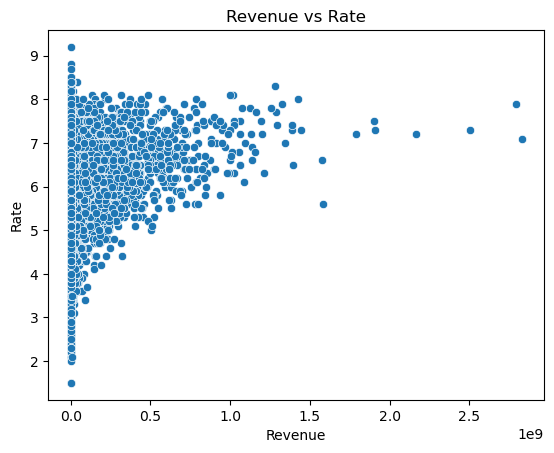

In [198]:
# Create a scatter plot to show the relationship between revenue and rate
sns.scatterplot(data=df, x='revenue', y='rate')
plt.title('Revenue vs Rate')
plt.xlabel('Revenue')
plt.ylabel('Rate')
plt.show()

## Insight: Revenue vs Rate

* There is a **weak positive relationship** between Revenue and Rate.
* Higher-revenue movies tend to have ratings **above 6**, but this is not always the case.
* A high revenue does **not necessarily mean a high rating**.
* Many movies have **Revenue = 0**, likely due to missing values replaced with zero.

### Conclusion

**Revenue alone is not enough to predict a movie's rating.**


<Axes: xlabel='rate', ylabel='revenue'>

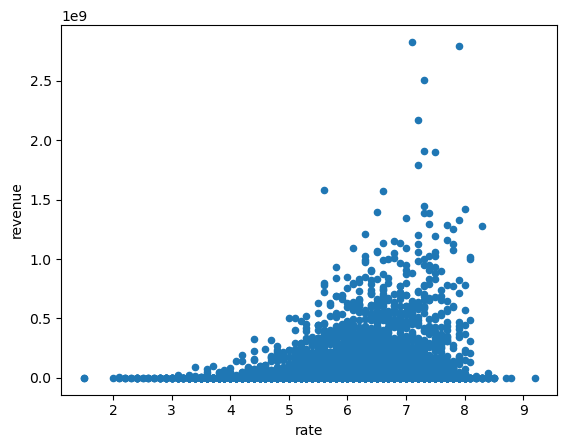

In [200]:
# Plot the relationship between rating and revenue using a scatter plot
df.plot(x='rate',y='revenue',kind='scatter')

## Insight: Rating vs Revenue

The plot shows a **weak positive relationship** between rating and revenue.

- Movies with ratings between **6 and 8** tend to achieve higher revenues.
- However, a high rating alone does not guarantee commercial success.
- Many highly rated movies still have relatively low revenues.
- The points at **revenue = 0** are likely missing revenue values that were replaced with zero.

### Conclusion

A higher rating tends to be associated with higher revenue, but **rating alone is not enough to predict a movie's revenue or commercial success**.

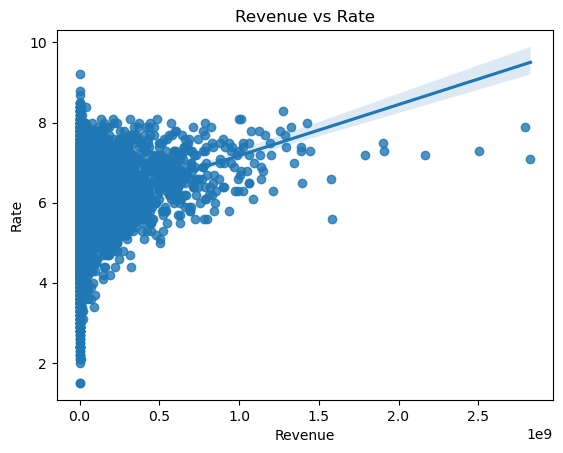

In [202]:
# Plot the relationship between revenue and rate with a regression line
sns.regplot(data=df, x='revenue', y='rate')
plt.title('Revenue vs Rate')
plt.xlabel('Revenue')
plt.ylabel('Rate')
plt.show()

## Regression Plot: Revenue vs Rate

* The regression line slopes upward, indicating a **weak positive relationship** between revenue and rating.
* Most data points are concentrated at low revenue levels, with a wide range of ratings.
* At higher revenue levels, there are fewer movies, so **outliers** may influence the regression line.
* The blue area represents the **confidence interval**, which becomes wider at higher revenue levels due to the limited amount of data.

### Conclusion

**Revenue has a weak positive relationship with Rate, but Revenue alone is not enough to predict a movie's rating.**


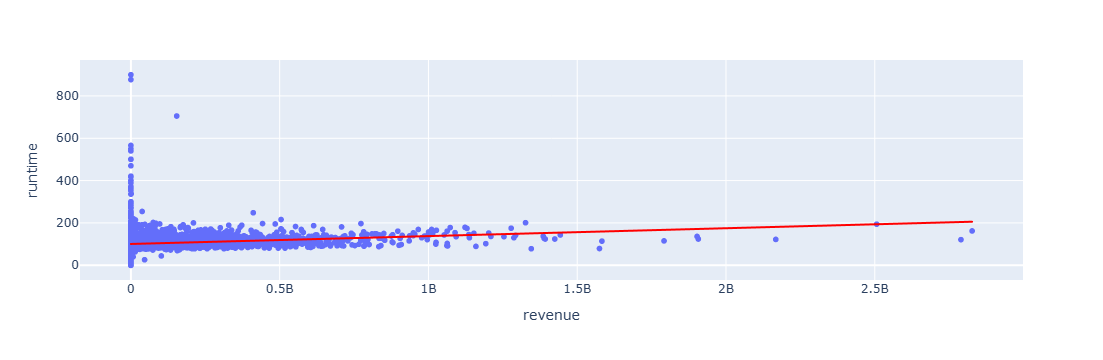

In [214]:
# Plot the relationship between rate and budget with a regression line
px.scatter(df, x='revenue', y='runtime',trendline='ols',trendline_color_override='red')

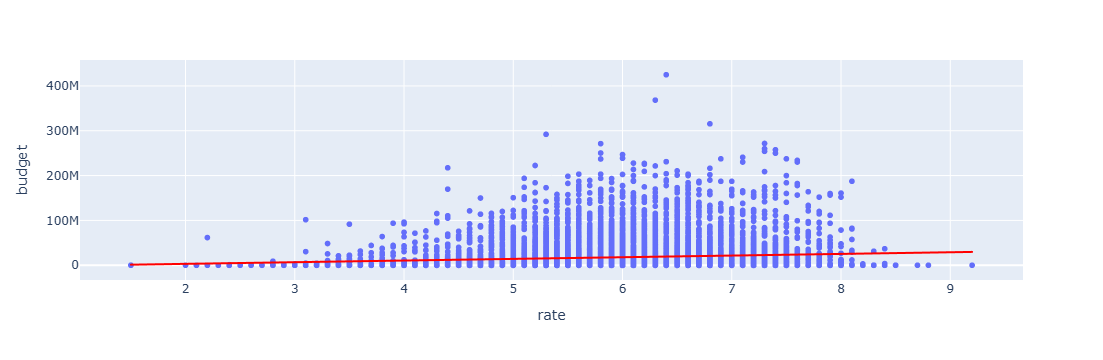

In [209]:
# Plot the relationship between rate and budget with a regression line
px.scatter(df, x='rate', y='budget',trendline='ols',trendline_color_override='red')

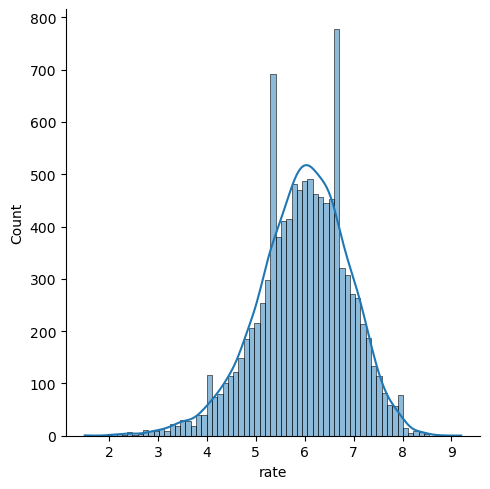

In [217]:
# Plot the distribution of movie ratings with a KDE curve
sns.displot(df['rate'], kde=True)
plt.show()

## 📊 Conclusion: Rate Distribution

* Most movies have ratings between **5 and 7**, with a clear concentration around **6**.
* The rating distribution is approximately **normal**, with a slight skew toward lower ratings.
* Ratings below **3** and above **8** are relatively rare.
* The noticeable spikes indicate that many movies have the same or very similar ratings.

### 💡 Business Insight

**Most movies receive moderate ratings, with ratings concentrated around 6. Extremely low and extremely high ratings are relatively uncommon.**


In [224]:
# Count the number of movies in each main genre
genre_count = df['main_genre'].value_counts()
genre_count

main_genre
D    2830
C    2693
A    2547
H     958
T     565
F     421
M     220
S     211
R     185
W     100
Name: count, dtype: int64

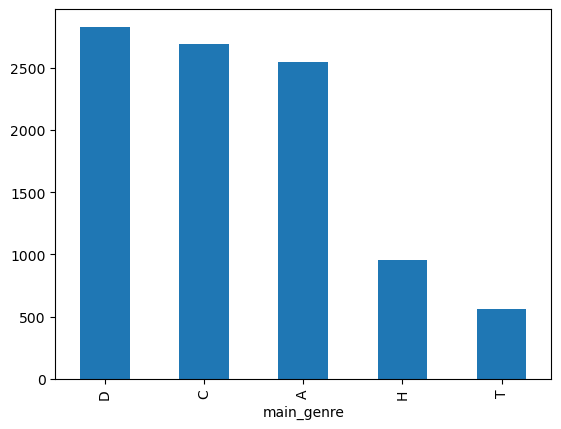

In [225]:
# Count the number of movies in each main genre and plot the top 5 genres
df['main_genre'].value_counts()[:5].plot(kind='bar')

plt.show()

### Insight: Top 5 Main Genres

The bar chart shows the number of movies in each of the top 5 main genres.

- The top three genres (D, C, A) have similar counts, between about 2,500 and 2,800 movies each.
- There is a sharp drop after the third genre: H has about 950 movies and T about 550.
- The dataset is dominated by a few genres, while the others are much less common.

**Conclusion:** A small number of genres account for most of the movies in the dataset.

In [226]:
# Count the number of movies in each main genre
genre_count = df['main_genre'].value_counts()
genre_count

main_genre
D    2830
C    2693
A    2547
H     958
T     565
F     421
M     220
S     211
R     185
W     100
Name: count, dtype: int64

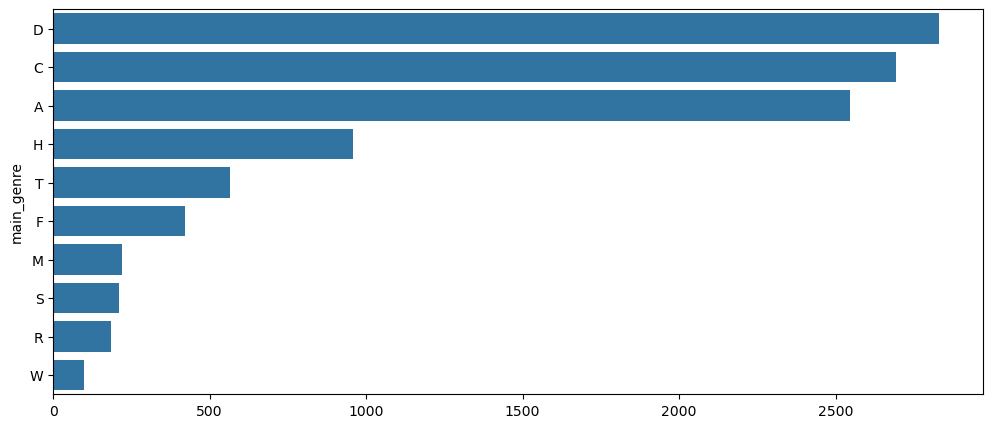

In [229]:
# Set the figure size
plt.figure(figsize=(12, 5))
sns.barplot(
    x=genre_count.values,
    y=genre_count.index
)
plt.show()

In [230]:
# Calculate the average rating for each main genre and sort in ascending order
genre_avg_rate = df.groupby('main_genre')['rate'].mean().sort_values(ascending=True)
genre_avg_rate

main_genre
H    5.368058
T    5.645310
F    5.836580
A    5.915430
C    5.928221
S    5.938389
R    6.136216
W    6.143000
M    6.189091
D    6.295972
Name: rate, dtype: float64

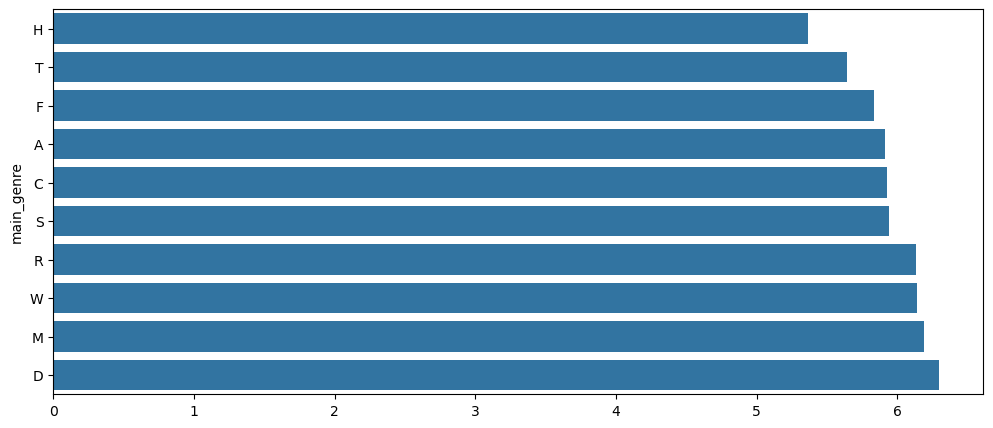

In [231]:
# Set the figure size
plt.figure(figsize=(12, 5))
sns.barplot( x=genre_avg_rate.values,y=genre_avg_rate.index)
plt.show()

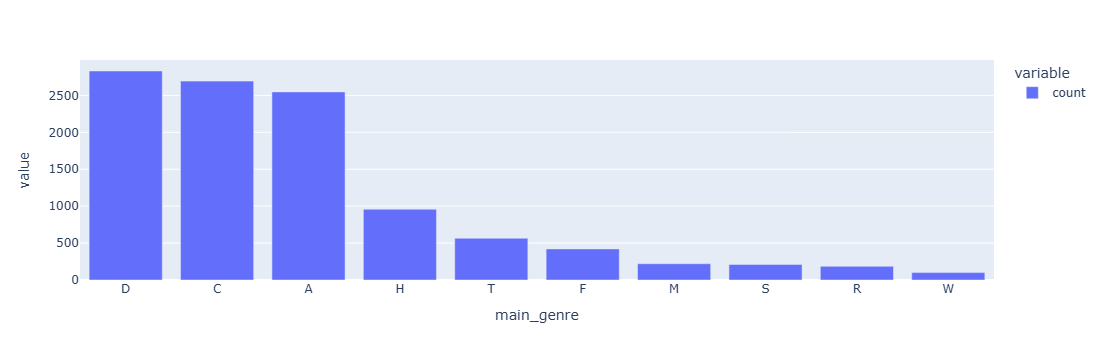

In [235]:
px.bar(genre_count)

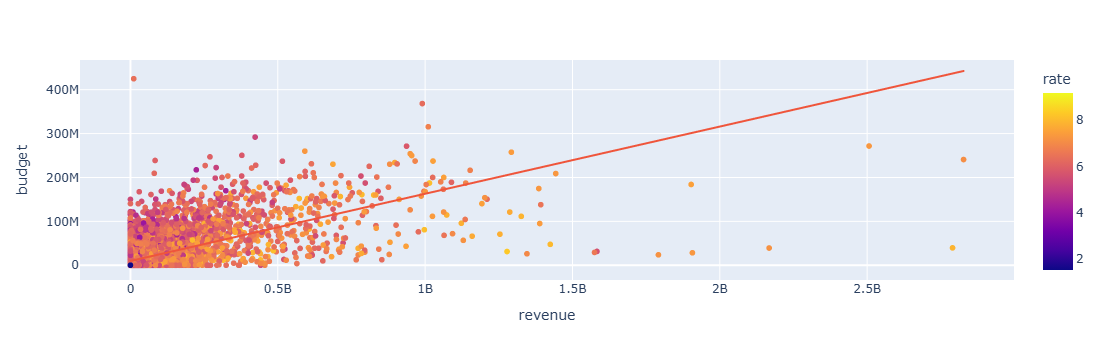

In [238]:
fig = px.scatter(df, x='revenue', y='budget', trendline='ols', color='rate', hover_data=['original_title']); fig.show()

In [239]:
df.corr(numeric_only=True)

,id,popularity,runtime,vote_count,rate,release_year,budget,revenue,day,month,year,profit,ROI
id,1.000000,-0.009459,-0.084053,-0.032757,-0.071853,0.510374,-0.186984,-0.137086,0.012579,0.042237,0.510374,-0.107122,-0.007512
popularity,-0.009459,1.000000,0.138205,0.800613,0.217847,0.093104,0.512074,0.608371,0.018428,0.042766,0.093104,0.562347,-0.002908
runtime,-0.084053,0.138205,1.000000,0.164947,0.177145,-0.119130,0.222588,0.177388,0.004674,0.065263,-0.119130,0.143914,0.003483
vote_count,-0.032757,0.800613,0.164947,1.000000,0.260520,0.110360,0.586274,0.707511,0.028149,0.026012,0.110360,0.656518,-0.003903
rate,-0.071853,0.217847,0.177145,0.260520,1.000000,-0.127670,0.099795,0.199393,-0.000393,0.075476,-0.127670,0.202928,-0.003757
release_year,0.510374,0.093104,-0.119130,0.110360,-0.127670,1.000000,0.019475,-0.064924,0.007342,-0.048471,1.000000,-0.080297,-0.018894
budget,-0.186984,0.512074,0.222588,0.586274,0.099795,0.019475,1.000000,0.645907,0.030406,0.056440,0.019475,0.472162,-0.013644
revenue,-0.137086,0.608371,0.177388,0.707511,0.199393,-0.064924,0.645907,1.000000,0.031321,0.050625,-0.064924,0.977933,0.008854
day,0.012579,0.018428,0.004674,0.028149,-0.000393,0.007342,0.030406,0.031321,1.000000,0.016006,0.007342,0.027846,0.005037
month,0.042237,0.042766,0.065263,0.026012,0.075476,-0.048471,0.056440,0.050625,0.016006,1.000000,-0.048471,0.043011,-0.005463


In [241]:
colocheck = ['rate', 'runtime', 'rate', 'budget']

In [243]:
corr_matrix = df[['rate', 'runtime', 'budget']].corr()

In [244]:
corr_matrix

,rate,runtime,budget
rate,1.000000,0.177145,0.099795
runtime,0.177145,1.000000,0.222588
budget,0.099795,0.222588,1.000000


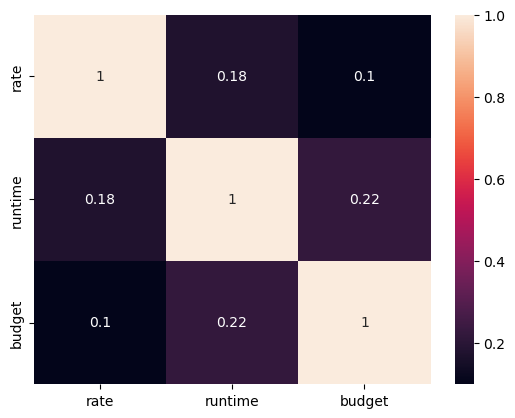

In [246]:
sns.heatmap(corr_matrix, annot=True); plt.show()

In [253]:
df.SuccessOrFail


0         Hit
1         Hit
2         Hit
3         Hit
4         Hit
         ... 
10861    Loss
10862    Loss
10863    Loss
10864    Loss
10865    Loss
Name: SuccessOrFail, Length: 10730, dtype: object

fig = px.pie(df, names='SuccessOrFail', hole=0.4); fig.show()

In [259]:
top_5_genre = genre_df['genres'].value_counts()[:5]

In [260]:
top_5_genre

genres
Drama        2443
Comedy       2312
Action       1587
Horror        914
Adventure     585
Name: count, dtype: int64

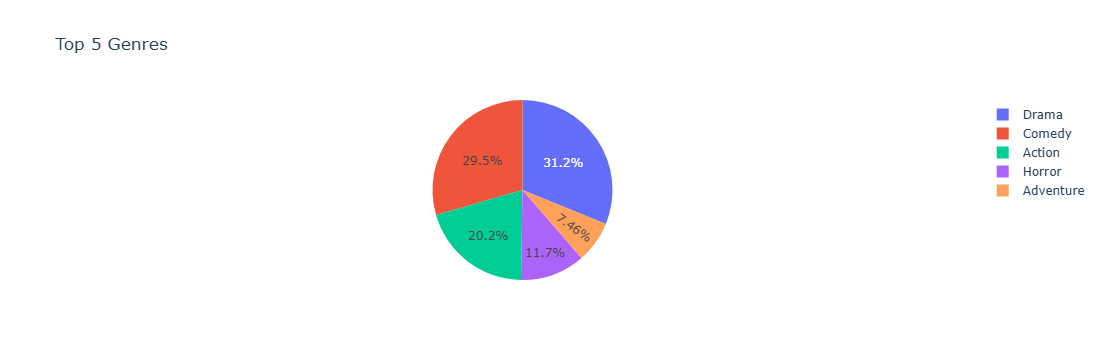

In [261]:
px.pie(names=top_5_genre.index, values=top_5_genre.values, title='Top 5 Genres')

In [263]:
yearly_rates = df.groupby('release_year')['rate'].mean()

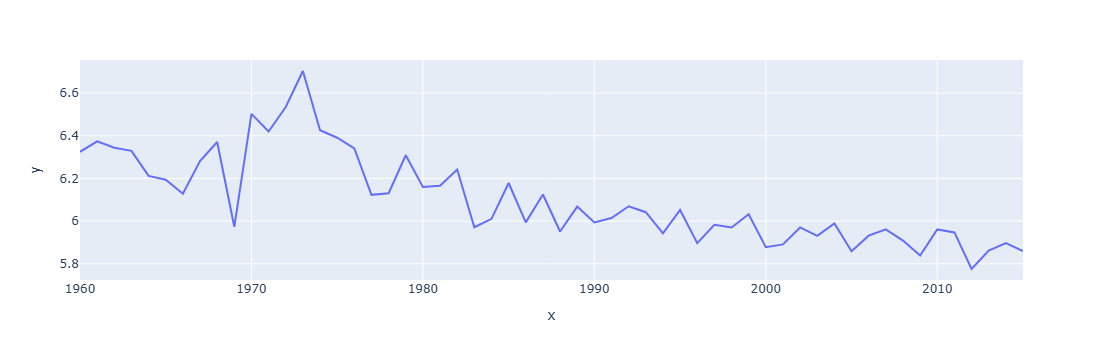

In [264]:
px.line(x=yearly_rates.index, y=yearly_rates.values)

## Final Conclusion

Through analyzing the movie dataset, we moved beyond simply presenting numbers and charts to understanding the **factors associated with movie success and the risks involved in the movie industry**.

The analysis shows that **commercial and audience success cannot be explained by a single factor**. Higher budgets are generally associated with higher revenues, but a large budget does not guarantee profitability. Similarly, a high rating does not necessarily lead to high revenue, and choosing a popular genre alone does not guarantee success.

One of the most important findings is the **high financial risk of movie production**, as a large proportion of movies in the dataset were classified as losses. This highlights the importance of using data to support production and investment decisions rather than relying only on assumptions or intuition.

### Business Impact

The real value of this analysis is not only understanding **what happened**, but also using the data to support **better future decisions**.

Companies and investors can use these insights to:

**Evaluate Risk → Optimize Budgets → Understand Audience Demand → Compare Genres → Identify Success Factors → Make Smarter Investment Decisions**

### Final Insight

**Successful movie production is not about simply spending more, choosing the most popular genre, or targeting the highest rating. It is about finding the right balance between budget, audience demand, content quality, and market potential.**

### Final Message

**By transforming historical movie data into actionable insights, production companies and investors can make more informed decisions, reduce financial risk, use budgets more effectively, and increase the probability of achieving both commercial and audience success.**


